In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df3 = pd.read_csv("D:\Downloads\collegePlace.csv")
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2966 non-null   int64 
 1   Gender             2966 non-null   object
 2   Stream             2966 non-null   object
 3   Internships        2966 non-null   int64 
 4   CGPA               2966 non-null   int64 
 5   Hostel             2966 non-null   int64 
 6   HistoryOfBacklogs  2966 non-null   int64 
 7   PlacedOrNot        2966 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 185.5+ KB


In [3]:
df2 = pd.read_csv("D:\Downloads\Placement_data_full_class.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [4]:
df2.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [5]:
# finding null in df2
null_values = df2.isnull()
# print(null_values)
null_values.sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df2['gender'] = label_encoder.fit_transform(df2['gender'])
df2['ssc_b'] = label_encoder.fit_transform(df2['ssc_b'])
df2['hsc_b'] = label_encoder.fit_transform(df2['hsc_b'])
df2['hsc_s'] = label_encoder.fit_transform(df2['hsc_s'])
df2['degree_t'] = label_encoder.fit_transform(df2['degree_t'])
df2['workex'] = label_encoder.fit_transform(df2['workex'])
df2['specialisation'] = label_encoder.fit_transform(df2['specialisation'])
df2['status'] = label_encoder.fit_transform(df2['status'])
df2['gender'].unique()
df2

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,2,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0
2,3,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1,250000.0
3,4,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0,NaN
4,5,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,1,80.60,1,82.00,1,1,77.60,0,0,91.0,0,74.49,1,400000.0
211,212,1,58.00,1,60.00,1,2,72.00,2,0,74.0,0,53.62,1,275000.0
212,213,1,67.00,1,67.00,1,1,73.00,0,1,59.0,0,69.72,1,295000.0
213,214,0,74.00,1,66.00,1,1,58.00,0,0,70.0,1,60.23,1,204000.0


<Axes: ylabel='salary'>

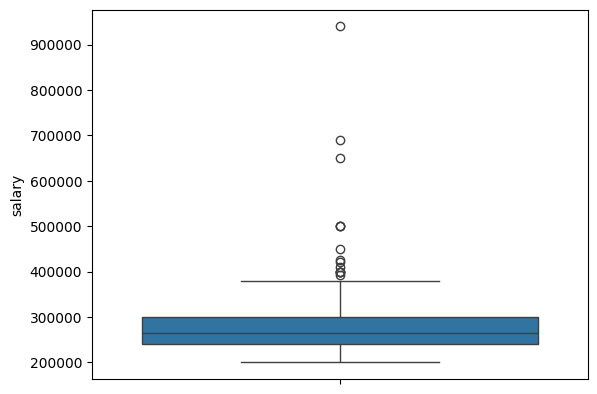

In [7]:
# handle missing values in salary
# check if salary has outliers
import seaborn as sns
sns.boxplot(df2['salary'])


In [8]:
# since it contains outliers, fill missing value with median
df2['salary'] = df2['salary'].fillna(df2['salary'].median())
df2['salary'].isnull().sum()

np.int64(0)

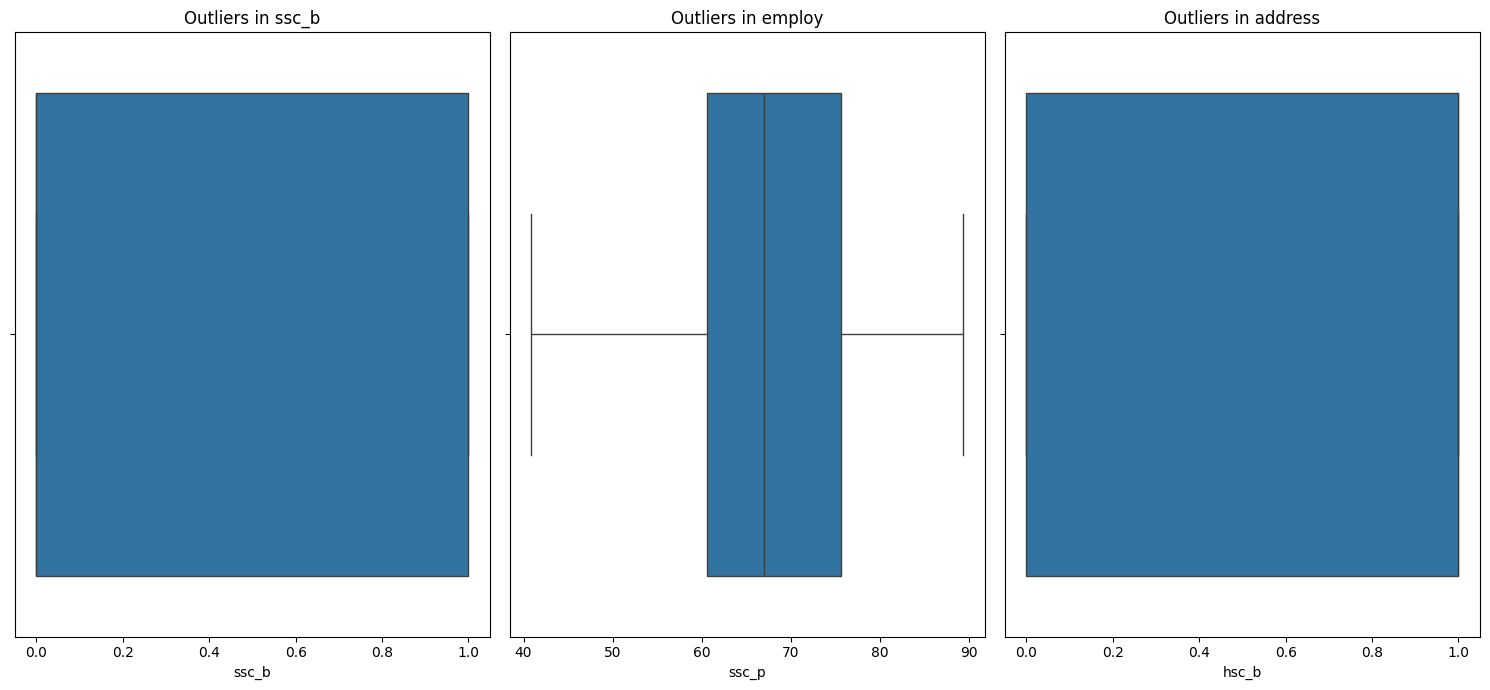

In [9]:

plt.figure(figsize=(15,7))
plt.subplot(1, 3, 1)
sns.boxplot(x=df2['ssc_b'])
plt.title("Outliers in ssc_b")

plt.subplot(1, 3, 2)
sns.boxplot(x=df2['ssc_p'])
plt.title("Outliers in employ")

plt.subplot(1, 3, 3)
sns.boxplot(x=df2['hsc_b'])
plt.title("Outliers in address")




plt.tight_layout()
plt.show()

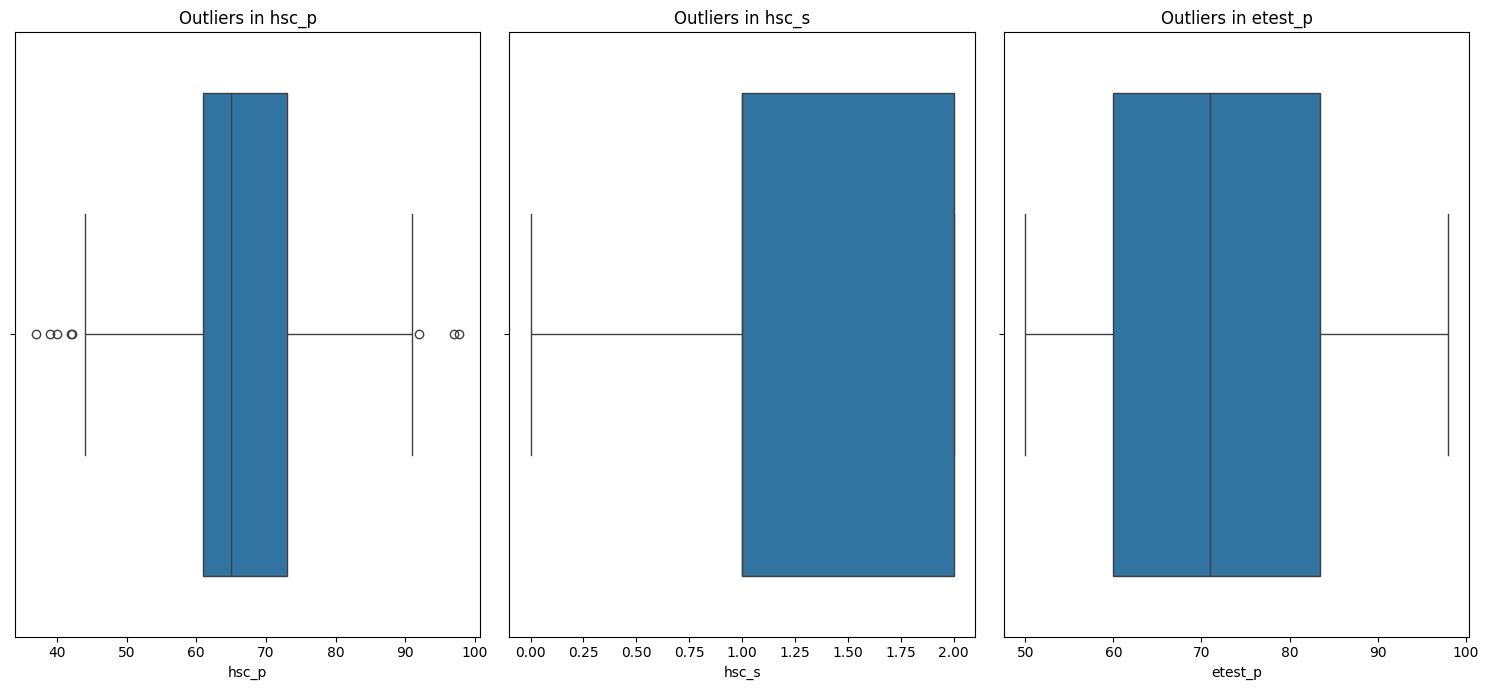

In [10]:

plt.figure(figsize=(15,7))
plt.subplot(1, 3, 1)
sns.boxplot(x=df2['hsc_p'])
plt.title("Outliers in hsc_p")

plt.subplot(1, 3, 2)
sns.boxplot(x=df2['hsc_s'])
plt.title("Outliers in hsc_s")

plt.subplot(1, 3, 3)
sns.boxplot(x=df2['etest_p'])
plt.title("Outliers in etest_p")




plt.tight_layout()
plt.show()

<Axes: ylabel='mba_p'>

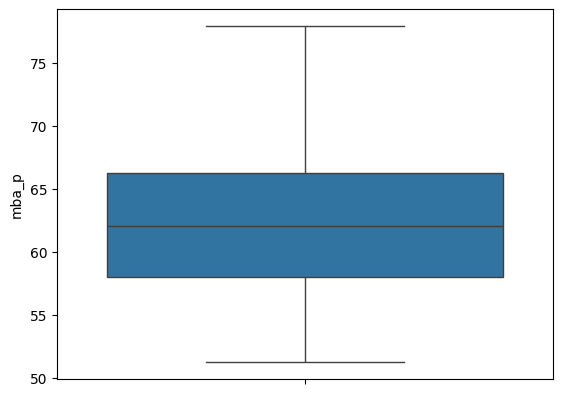

In [11]:
sns.boxplot(df2['mba_p'])

In [12]:
#hsc_p has outliers
df2['hsc_p'].head()
outliers = []
def detect_outliers_iqr(data):
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    # print(q1, q3)
    IQR = q3-q1
    lwr_bound = q1-(1.5*IQR)
    upr_bound = q3+(1.5*IQR)
    # print(lwr_bound, upr_bound)
    for i in data:
        if (i<lwr_bound or i>upr_bound):
            outliers.append(i)
    return outliers# Driver code




In [13]:
hsc_p_outliers = detect_outliers_iqr(df2['hsc_p'])
print("Outliers from IQR method: ", hsc_p_outliers)

Outliers from IQR method:  [37.0, 39.0, 40.0, 42.0, 42.16, 92.0, 97.0, 97.7]


In [14]:
def handling_outliers(data,outliers):
    median = np.median(data)
    # print(median)
   # Replace with median
    for i in outliers:  
        c = np.where(data==i, median, data)
  

In [15]:
handling_outliers(df2['hsc_p'],detect_outliers_iqr(df2['hsc_p']))


In [16]:
x = df2.iloc[:,0:13] 
y = df2.iloc[:,-2]
x
y

# now the data is cleaned# step 4) train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)


In [17]:
x_train
x_train.shape
# y_train.shape

(172, 13)

In [18]:
x_test
x_test.shape
# y_test.shape

(43, 13)

In [19]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train,y_train)

LogisticRegression()

In [21]:
# now test the model
clf.predict(x_test)
# store this in a variable
y_predict = clf.predict(x_test)

In [ ]:
y_test

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.8604651162790697